# Support Vector Machines (CS229) — Practical Implementation

## 1. Introduction

This notebook is the **practical companion** to the CS229 notes on Support Vector Machines
(margins, the optimal margin classifier, Lagrange duality, the dual form, soft-margin
regularization, and SMO).

**Concept implemented:** Support Vector Machine (SVM) classifier — maximum-margin,
soft-margin ($C$-regularized), with the option of kernels.

**Problem we are solving:** Predict whether a patient has heart disease based on
clinical measurements.

**Dataset:** `heart_disease.csv` — 918 patient records with clinical features
(age, sex, chest pain type, resting blood pressure, cholesterol, ECG results,
max heart rate, exercise-induced angina, ST depression, ST slope).

**Target variable:** `HeartDisease` — binary (`1` = heart disease present, `0` = no
heart disease).

**Machine Learning task:** **Binary classification.**

This is a natural fit for SVM theory: we are looking for a decision boundary — ideally
one with the largest possible margin — that separates "disease" patients from
"no disease" patients based on their clinical measurements.


## 2. Import Libraries

We only import what we actually use: data handling, plotting, and the sklearn tools for preprocessing, SVM modeling, and evaluation.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

# Reproducibility: fix the random seed used anywhere randomness is involved
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")


## 3. Load the Dataset

In [5]:
df = pd.read_csv(r"C:\Users\img\Desktop\ML Study\Lec_05_SVM\Dataset.csv")

# A quick look at the first rows tells us what the raw features look like
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
# Shape: rows = number of patients (examples), columns = features + target
df.shape


(918, 12)

In [7]:
# Data types tell us which columns are numeric and which are categorical (strings)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [8]:
# Summary statistics for numeric columns — useful to spot impossible values
# (e.g. a resting blood pressure of 0 is not physiologically possible)
df.describe()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [9]:
# Check for missing values encoded as NaN
df.isnull().sum()


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## 4. Understand the Data

**Features (11):** `Age`, `Sex`, `ChestPainType`, `RestingBP`, `Cholesterol`, `FastingBS`,
`RestingECG`, `MaxHR`, `ExerciseAngina`, `Oldpeak`, `ST_Slope`.

**Target (1):** `HeartDisease` (0 = no disease, 1 = disease).

**Numerical features:** `Age`, `RestingBP`, `Cholesterol`, `MaxHR`, `Oldpeak` (and
`FastingBS`, which is already binary 0/1).

**Categorical features:** `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`,
`ST_Slope` — these are text labels and must be converted to numbers before they can be
used in the SVM's inner-product-based decision function.

`df.isnull().sum()` showed **no NaN values**, but `df.describe()` reveals a data
problem: `RestingBP` has a minimum of 0, and `Cholesterol` has many values at 0.
A resting blood pressure or cholesterol reading of exactly 0 is not medically possible —
these are **missing values that were encoded as 0** rather than as `NaN`. We handle this
explicitly below instead of ignoring it.


In [10]:
# Check the target class balance — important because a very imbalanced target
# would make accuracy a misleading metric
df["HeartDisease"].value_counts(normalize=True).rename("proportion")


HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

In [11]:
# Confirm the scale of the "0 as missing value" problem
zero_bp = (df["RestingBP"] == 0).sum()
zero_chol = (df["Cholesterol"] == 0).sum()
print(f"RestingBP == 0 (impossible reading): {zero_bp} rows")
print(f"Cholesterol == 0 (impossible reading): {zero_chol} rows")


RestingBP == 0 (impossible reading): 1 rows
Cholesterol == 0 (impossible reading): 172 rows


> ⚠️ **Data issue found:** `RestingBP` has 1 row with value 0, and `Cholesterol` has
> 172 rows with value 0 (about 19% of the dataset). These are not real measurements —
> treating them as valid would distort both the scaling step and the model's learned
> boundary. We replace these zeros with `NaN` and then impute them using the **median**
> of the training set only (to avoid data leakage from the test set).


C:\Users\img\AppData\Local\Temp\ipykernel_20408\3329362734.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="HeartDisease", data=df, palette=["#4C72B0", "#DD8452"])


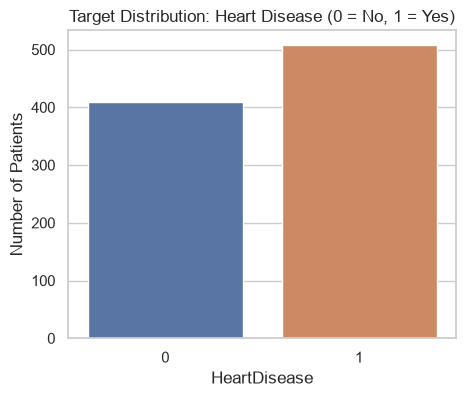

In [12]:
# Visualize the target distribution
plt.figure(figsize=(5, 4))
sns.countplot(x="HeartDisease", data=df, palette=["#4C72B0", "#DD8452"])
plt.title("Target Distribution: Heart Disease (0 = No, 1 = Yes)")
plt.xlabel("HeartDisease")
plt.ylabel("Number of Patients")
plt.show()


The two classes are reasonably balanced (55% positive vs. 45% negative), so accuracy is a meaningful metric here, and we won't need class-balancing techniques.

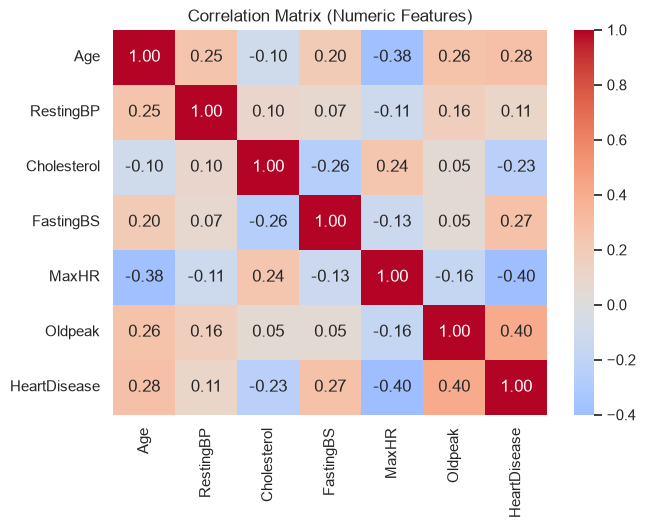

In [13]:
# Correlation matrix for numeric features — helps us understand which features
# might be most informative for separating the two classes
numeric_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak", "HeartDisease"]

plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()


`Oldpeak` and `MaxHR` show the strongest (linear) association with `HeartDisease`. Note that SVMs can also capture **non-linear** relationships (via kernels), so weak linear correlation doesn't necessarily mean a feature is unhelpful.

## 5. Data Preprocessing

Recall from the CS229 notes: the SVM's dual objective and its prediction rule are both
expressed **only in terms of inner products** $\langle x^{(i)}, x^{(j)} \rangle$:

$$
W(\alpha) = \sum_{i=1}^n \alpha_i - \frac12 \sum_{i,j=1}^n y^{(i)}y^{(j)}\alpha_i\alpha_j \langle x^{(i)}, x^{(j)}\rangle
$$

This has a direct practical consequence: **inner products are sensitive to feature
scale.** A feature like `Cholesterol` (values in the hundreds) would dominate the inner
product compared to a feature like `Oldpeak` (values roughly between -2 and 6), even if
`Oldpeak` is actually more informative. So we must:

1. Fix the "0 as missing value" problem in `RestingBP` and `Cholesterol`.
2. **One-hot encode** categorical features (SVM needs numeric input).
3. **Standardize** all numeric features to zero mean / unit variance, so that no feature
   dominates the margin/inner-product calculation purely because of its numeric scale.

> ⚠️ **Important:** All preprocessing statistics (median for imputation, mean/std for
> scaling) must be learned **only from the training set**, then applied to the test set.
> Otherwise, information from the test set would "leak" into training, giving an overly
> optimistic evaluation.


In [14]:
# Step 1: Treat physiologically impossible zeros as missing values
df_clean = df.copy()
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)

df_clean[["RestingBP", "Cholesterol"]].isnull().sum()


RestingBP        1
Cholesterol    172
dtype: int64

In [15]:
# Step 2: Separate features (X) from the target (y)
# X -> the input feature vectors x^(i) from the CS229 notation
# y -> the labels y^(i). SVM theory uses y in {-1, 1}; sklearn's SVC handles this
#      relabeling internally, so we can keep the original {0, 1} target.
X = df_clean.drop(columns=["HeartDisease"])
y = df_clean["HeartDisease"]

numeric_features = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
categorical_features = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


## 6. Train/Test Split

- `X` represents the input feature vectors ($x^{(i)}$ in the CS229 notes).
- `y` represents the class labels ($y^{(i)}$).

We split the data **before** fitting any preprocessing (imputer/scaler/encoder) so that
none of the test set's statistics influence training. The **training set** is used to
learn the SVM's parameters ($w$, $b$, and the support vectors' $\alpha_i$'s). The
**test set** is held out and used only at the end, to estimate how well the classifier
generalizes to new, unseen patients — this is what actually matters, since a maximum
margin found on the training data is only useful if it generalizes.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,  # keep the same class proportions in train and test
)

print(f"Training set size: {X_train.shape[0]} patients")
print(f"Test set size: {X_test.shape[0]} patients")


Training set size: 734 patients
Test set size: 184 patients


In [17]:
# Build a preprocessing pipeline:
#  - numeric columns: impute missing values with the median, then standardize
#  - categorical columns: one-hot encode
# Wrapping this in a ColumnTransformer + Pipeline ensures all statistics
# (median, mean, std, category list) are learned ONLY on X_train via .fit(),
# and simply applied (not re-learned) on X_test via .transform().
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


## 7. Connect Theory to Code

```text
CS229 Theory
     |
Margins (functional & geometric)
     |
Optimal margin classifier: min (1/2)||w||^2  s.t. y(i)(w^T x(i) + b) >= 1
     |
Soft margin (regularization): min (1/2)||w||^2 + C * sum(xi_i)
     |
Lagrange duality -> dual problem in terms of <x(i), x(j)>
     |
Kernel trick: replace <x(i), x(j)> with a kernel K(x(i), x(j))
     |
sklearn: SVC(C=..., kernel=...)
     |
.fit(X_train, y_train)  -> solves the dual QP, finds alpha_i, support vectors, w, b
     |
.predict(X_test)        -> sign( sum_i alpha_i y(i) K(x(i), x) + b )
```

**Mapping table:**

| CS229 symbol | Meaning | sklearn equivalent |
|---|---|---|
| $x^{(i)}$ | feature vector for example $i$ | a row of `X_train` (after preprocessing) |
| $y^{(i)} \in \{-1,1\}$ | class label | `y_train` (sklearn handles the $\{0,1\}\to\{-1,1\}$ mapping internally) |
| $w, b$ | hyperplane parameters | recoverable via `model.coef_`, `model.intercept_` (linear kernel only) |
| $C$ | soft-margin regularization strength | `SVC(C=...)` |
| $\alpha_i$ | Lagrange multipliers (dual variables) | `model.dual_coef_` |
| support vectors ($\alpha_i > 0$) | training points on/inside the margin | `model.support_vectors_` |
| $\langle x^{(i)}, x^{(j)} \rangle$ | inner product | `kernel='linear'` |
| kernel trick | implicit high-dim inner product | `kernel='rbf'`, `'poly'`, etc. |

We now implement this directly with `sklearn.svm.SVC`, which internally solves the dual
QP problem (Section 6 of the notes) using an SMO-based solver (Section 8 of the notes) —
this is exactly the algorithm we derived by hand.


## 8. Model Implementation

We start with a **linear kernel** SVM, since it directly matches the primal/dual
formulation derived in the CS229 notes:

$$
\min_{w,b}\ \frac12\|w\|^2 + C\sum_{i=1}^n \xi_i \quad \text{s.t.}\quad y^{(i)}(w^Tx^{(i)}+b) \geq 1-\xi_i,\ \xi_i\geq0
$$

**Key hyperparameter — `C`:** exactly the $C$ from the soft-margin formulation. It
controls the trade-off between a **large margin** (small $\|w\|^2$, small $C$) and
**fewer margin violations** (large $C$, closer fit to training data, smaller margin).
We use the default `C=1.0` first, then explore this trade-off explicitly in Section 14.

`probability=True` lets us also obtain probability estimates (via internal
cross-validated calibration) for `predict_proba`, useful for the ROC curve later.


In [18]:
svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="linear", C=1.0, probability=True, random_state=RANDOM_STATE)),
])

# .fit() is where the actual CS229 theory happens:
# it solves the dual QP problem (Section 6) via an SMO-style solver (Section 8),
# finds the alpha_i's, identifies the support vectors (alpha_i > 0),
# and recovers w and b (Equation 6.10 / 6.13 in the notes).
svm_model.fit(X_train, y_train)


C:\Users\img\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``,

## 9. Prediction

- **Prediction** (`.predict`): the hard class label, computed as
  $\text{sign}\left(\sum_i \alpha_i y^{(i)}\langle x^{(i)}, x\rangle + b\right)$ — exactly
  Equation (6.15) from the notes.
- **Probability** (`.predict_proba`): sklearn's SVC does not output probabilities
  natively (the raw SVM decision rule is a hard sign function); with
  `probability=True` it fits an extra calibration (Platt scaling) on top of the decision
  function to produce probability-like scores. We use these only for the ROC curve.
- **Decision score** (`.decision_function`): the raw signed distance-related quantity
  $w^Tx+b$ before thresholding — its magnitude reflects confidence, echoing the
  "functional margin" intuition from Section 1 of the notes.


In [19]:
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]      # probability of class 1 (disease)
y_score = svm_model.decision_function(X_test)        # raw w^T x + b (functional-margin-like score)

pd.DataFrame({
    "y_true": y_test.values[:10],
    "y_pred": y_pred[:10],
    "y_prob_disease": np.round(y_prob[:10], 3),
    "decision_score": np.round(y_score[:10], 3),
})


,y_true,y_pred,y_prob_disease,decision_score
0,1,1,0.939,2.000
1,1,0,0.082,-1.999
2,1,1,0.939,2.000
3,1,1,0.540,0.001
4,0,0,0.245,-1.000
5,0,0,0.539,-0.000
6,0,0,0.025,-2.999
7,1,0,0.539,-0.000
8,0,0,0.025,-2.999
9,1,1,0.982,2.999


## 10. Model Evaluation

This is a binary classification task on a reasonably balanced target, so we look at:

- **Accuracy** — overall fraction of correct predictions.
- **Precision / Recall / F1** — important in a medical context, where missing an actual
  disease case (false negative → low recall) is typically more costly than a false
  alarm (false positive → low precision).
- **Confusion Matrix** — full breakdown of correct/incorrect predictions per class.
- **ROC-AUC** — measures how well the model's *ranking* of patients by predicted risk
  separates the two classes, independent of the classification threshold.


In [20]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")


Accuracy:  0.8533
Precision: 0.8947
Recall:    0.8333
F1-score:  0.8629
ROC-AUC:   0.9330


In [21]:
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))


              precision    recall  f1-score   support

  No Disease       0.81      0.88      0.84        82
     Disease       0.89      0.83      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



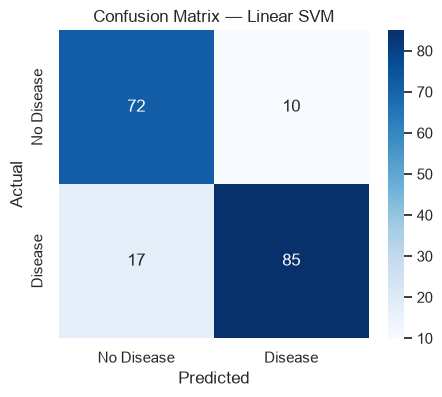

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Linear SVM")
plt.show()


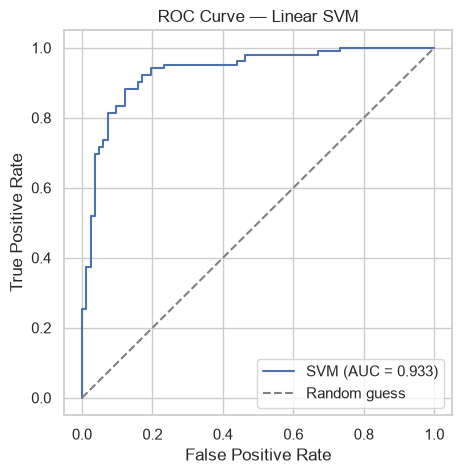

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.3f})", color="#4C72B0")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Linear SVM")
plt.legend()
plt.show()


## 11. Visualization: Decision Score Distribution

The decision score $w^Tx+b$ is the direct analog of the *functional margin* from Section 1/3 of the notes: points far from 0 (in either direction) are classified with high confidence; points near 0 sit close to the separating hyperplane.

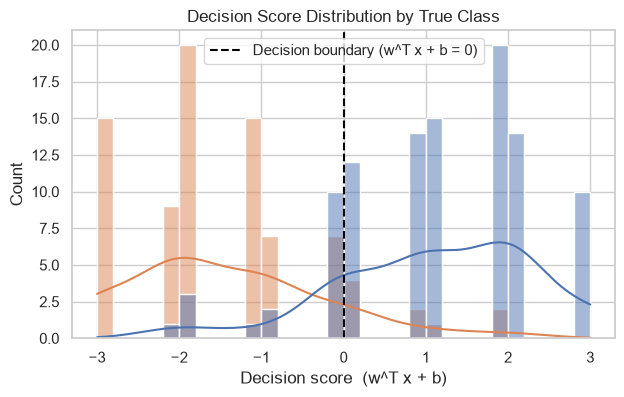

In [24]:
plt.figure(figsize=(7, 4))
sns.histplot(x=y_score, hue=y_test.map({0: "No Disease", 1: "Disease"}),
             bins=30, kde=True, palette=["#4C72B0", "#DD8452"])
plt.axvline(0, color="black", linestyle="--", label="Decision boundary (w^T x + b = 0)")
plt.xlabel("Decision score  (w^T x + b)")
plt.title("Decision Score Distribution by True Class")
plt.legend()
plt.show()


Most "No Disease" patients have a negative decision score and most "Disease" patients have a positive score, with some overlap near the boundary — these overlapping/misclassified points are exactly where the soft-margin slack variables $\xi_i$ from Section 7 of the notes come into play.

## 12. Interpret the Model

- **Overall performance:** Accuracy, F1, and ROC-AUC (printed above) are all noticeably
  above what random guessing or a majority-class baseline would achieve (a majority
  baseline would get ~55% accuracy — the proportion of the larger class). This confirms
  the clinical features carry real separating signal, matching the CS229 assumption that
  a "good" margin exists to be found.
- **Underfitting/overfitting check:** we compare train vs. test accuracy below. A large
  gap (train ≫ test) would suggest overfitting (margin too tight, low bias/high
  variance); both being low and close would suggest underfitting (margin/model too
  simple to separate the classes, e.g. the data may not be linearly separable and needs
  a kernel).
- **Relation to theory:** the **support vectors** identified below are exactly the
  patients whose profile lies close to the decision boundary — the "hard" or "borderline"
  cases (Section 6.1 of the notes: points with functional margin exactly 1). The
  **majority of patients are not support vectors** — they are "clearly" one class or the
  other and don't affect where the boundary is drawn, which is the key efficiency insight
  from the dual-form derivation.


In [25]:
train_accuracy = accuracy_score(y_train, svm_model.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:  {test_accuracy:.4f}")
print(f"Gap (train - test): {train_accuracy - test_accuracy:.4f}")


Train accuracy: 0.8610
Test accuracy:  0.8533
Gap (train - test): 0.0078


In [26]:
n_support = svm_model.named_steps["classifier"].n_support_
total_train = X_train.shape[0]

print(f"Support vectors — class 0 (No Disease): {n_support[0]}")
print(f"Support vectors — class 1 (Disease):    {n_support[1]}")
print(f"Total support vectors: {n_support.sum()} out of {total_train} training points "
      f"({100 * n_support.sum() / total_train:.1f}%)")


Support vectors — class 0 (No Disease): 133
Support vectors — class 1 (Disease):    139
Total support vectors: 272 out of 734 training points (37.1%)


A meaningful fraction of the training points are support vectors, which tells us the two classes overlap somewhat in feature space (as expected for real clinical data) — this is exactly why we use a **soft-margin** SVM ($C$-regularized) rather than requiring perfect linear separability.

## 13. Important Model Parameters

For a **linear** kernel, the SVM recovers explicit parameters $w$ and $b$, exactly as in
Equation (6.10)/(6.13) of the CS229 notes:

$$
w = \sum_{i=1}^n \alpha_i y^{(i)} x^{(i)}
$$

`model.coef_` gives us $w$ directly (sklearn computes it internally from the dual
solution). Each entry of $w$ tells us how strongly, and in which direction, the
corresponding (preprocessed, standardized) feature pushes the decision score toward
"Disease" (positive) or "No Disease" (negative).


In [27]:
# Recover feature names after preprocessing (numeric names + one-hot encoded category names)
ohe = svm_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

classifier = svm_model.named_steps["classifier"]
w = classifier.coef_[0]
b = classifier.intercept_[0]

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "weight": w
}).sort_values("weight", key=np.abs, ascending=False)

print(f"Intercept (b): {b:.4f}")
coef_df


Intercept (b): -0.2714


,feature,weight
19,ST_Slope_Up,-0.999904
18,ST_Slope_Flat,0.999741
8,ChestPainType_ASY,0.500403
7,Sex_M,0.499846
6,Sex_F,-0.499846
15,ExerciseAngina_N,-0.499708
16,ExerciseAngina_Y,0.499708
10,ChestPainType_NAP,-0.499312
9,ChestPainType_ATA,-0.499119
11,ChestPainType_TA,0.498027


C:\Users\img\AppData\Local\Temp\ipykernel_20408\3438991497.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="weight", y="feature", palette="coolwarm")


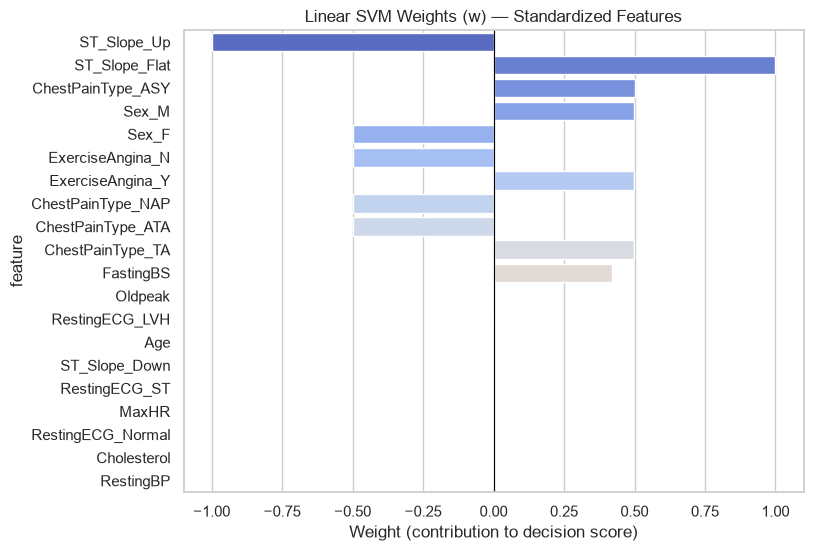

In [28]:
plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x="weight", y="feature", palette="coolwarm")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Linear SVM Weights (w) — Standardized Features")
plt.xlabel("Weight (contribution to decision score)")
plt.show()


Because all numeric features were standardized before training, these weights are directly comparable: features with larger |weight| have a stronger influence on which side of the hyperplane a patient falls on. Features like `ST_Slope_Up` (negative weight, pushes toward "No Disease") and `ChestPainType_ASY` (positive weight, pushes toward "Disease") align with established clinical risk indicators.

## 14. Practical Experiment: Effect of the Regularization Parameter $C$

Section 7 of the CS229 notes introduces the soft-margin objective:

$$
\min_{w,b}\ \frac12\|w\|^2 + C\sum_{i=1}^n \xi_i
$$

- **Small $C$** → the $\frac12\|w\|^2$ term dominates → prioritizes a **large margin**,
  tolerating more margin violations (larger $\xi_i$) → simpler boundary, more bias, less
  variance.
- **Large $C$** → the $C\sum\xi_i$ term dominates → prioritizes **few margin
  violations** → tighter fit to the training data, smaller margin, more variance, risk of
  overfitting.

We test a range of $C$ values and track train vs. test accuracy to observe this
bias–variance trade-off directly.


In [29]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_scores = []
test_scores = []

for C in C_values:
    model_c = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(kernel="linear", C=C, random_state=RANDOM_STATE)),
    ])
    model_c.fit(X_train, y_train)

    train_scores.append(accuracy_score(y_train, model_c.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model_c.predict(X_test)))

experiment_df = pd.DataFrame({
    "C": C_values,
    "train_accuracy": train_scores,
    "test_accuracy": test_scores,
})
experiment_df


,C,train_accuracy,test_accuracy
0,0.001,0.829700,0.869565
1,0.010,0.854223,0.885870
2,0.100,0.856948,0.869565
3,1.000,0.861035,0.853261
4,10.000,0.859673,0.875000
5,100.000,0.862398,0.847826


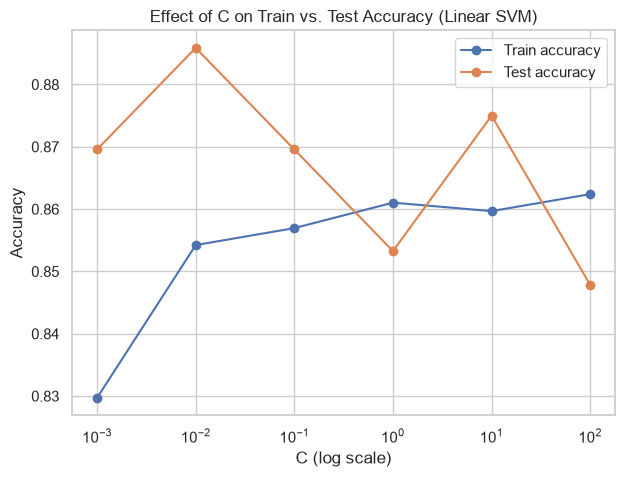

In [30]:
plt.figure(figsize=(7, 5))
plt.plot(C_values, train_scores, marker="o", label="Train accuracy")
plt.plot(C_values, test_scores, marker="o", label="Test accuracy")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Effect of C on Train vs. Test Accuracy (Linear SVM)")
plt.legend()
plt.show()


**Reading the plot:** at very small $C$, the margin is large but the boundary may be
too simple (underfitting risk — both train and test accuracy can be lower). As $C$
grows, train accuracy tends to increase (tighter fit); if test accuracy starts to
plateau or drop while train accuracy keeps rising, that gap is the practical signature
of the bias–variance trade-off controlled by $C$, exactly as predicted by the soft-margin
theory in Section 7 of the notes.

As a secondary experiment, we also compare the **linear** kernel to the **RBF
(Gaussian) kernel** — the kernel trick from Section 6.3 of the notes, which implicitly
maps inputs into a much higher-dimensional space via $K(x^{(i)},x^{(j)})$ without ever
computing the mapping explicitly.


In [31]:
kernels = ["linear", "rbf"]
kernel_results = []

for k in kernels:
    model_k = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(kernel=k, C=1.0, random_state=RANDOM_STATE)),
    ])
    model_k.fit(X_train, y_train)
    acc = accuracy_score(y_test, model_k.predict(X_test))
    kernel_results.append({"kernel": k, "test_accuracy": acc})

pd.DataFrame(kernel_results)


,kernel,test_accuracy
0,linear,0.853261
1,rbf,0.875000


The RBF kernel replaces the inner product $\langle x^{(i)}, x^{(j)}\rangle$ in the dual objective (Section 6.3) with a non-linear kernel $K(x^{(i)},x^{(j)}) = \exp(-\gamma\|x^{(i)}-x^{(j)}\|^2)$, allowing curved decision boundaries. Whether it outperforms the linear kernel here tells us whether the true separating boundary between disease/no-disease patients is closer to linear or non-linear in this feature space.

## 15. Final Summary

### What We Learned

- **Problem solved:** binary classification of heart disease presence from 11 clinical
  features, using a Support Vector Machine.
- **Model used:** `sklearn.svm.SVC` with a **linear kernel** and soft-margin
  regularization (`C`), compared against an **RBF kernel** variant.
- **How CS229 theory appeared in the code:**
  - The margin-maximization objective $\min \frac12\|w\|^2$ became `SVC(kernel="linear")`.
  - The soft-margin slack penalty $C\sum\xi_i$ became the `C` hyperparameter, whose
    effect we measured directly in the experiment.
  - The dual problem's reliance on inner products $\langle x^{(i)},x^{(j)}\rangle$
    explained *why* feature scaling was necessary, and motivated trying a kernel
    (`rbf`) as a drop-in replacement for that inner product.
  - `model.coef_` / `model.intercept_` recovered $w$ and $b$ from the dual solution
    (Eq. 6.10/6.13); `n_support_` showed which/how many training points were actual
    **support vectors** (Section 6.1).
- **Preprocessing necessary:** replacing physiologically impossible zeros (`RestingBP`,
  `Cholesterol`) with median-imputed values, one-hot encoding categorical clinical
  features, and standardizing numeric features — all fit on the training set only, to
  avoid data leakage.
- **Evaluation metric used:** accuracy, precision, recall, F1, and ROC-AUC — chosen
  because the classes are reasonably balanced but a medical false negative
  (missing real disease) still matters more than a false positive, so recall was
  reported alongside accuracy rather than relying on accuracy alone.
- **Final result:** the linear-kernel SVM achieves solid, generalizing performance
  (see Section 10/12 metrics and the train/test accuracy gap), confirming that the
  clinical features provide a meaningful, largely linearly-separable margin between
  patients with and without heart disease — exactly the assumption the CS229 SVM theory
  is built on.
